# Importing Required Libraries

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error

# Loading the Dataset

In [2]:
df = pd.read_csv('HousingData.csv')
print(f"Dataset loaded into dataframe df, having shape {df.shape}")

Dataset loaded into dataframe df, having shape (506, 14)


# Exploring the Dataframe

## Dimension and Size

In [3]:
print(f"No. of Rows : {df.shape[0]}\nNo. of Columns : {df.shape[1]}\nTotal No. of Cells : {df.size}")

No. of Rows : 506
No. of Columns : 14
Total No. of Cells : 7084


## Displaying Sample Rows

In [5]:
print("Top 5 rows")
display(df.head())

Top 5 rows


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [6]:
print("Last 5 rows")
display(df.tail())

Last 5 rows


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,NaN,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0
505,0.04741,0.0,11.93,0.0,0.573,6.030,NaN,2.5050,1,273,21.0,396.90,7.88,11.9


In [8]:
print("Randomly selected 5 rows")
display(df.sample(5))

Randomly selected 5 rows


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
441,9.72418,0.0,18.10,0.0,0.740,6.406,97.2,2.0651,24,666,20.2,385.96,NaN,17.1
162,1.83377,0.0,19.58,1.0,0.605,7.802,98.2,2.0407,5,403,14.7,389.61,1.92,50.0
371,9.23230,0.0,18.10,0.0,0.631,6.216,100.0,1.1691,24,666,20.2,366.15,9.53,50.0
45,0.17142,0.0,6.91,0.0,0.448,5.682,33.8,5.1004,3,233,17.9,396.90,10.21,19.3
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4


## Metadata

In [9]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  PRICE    506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


None

## Statistical Summary

In [11]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
CRIM,486.0,3.611874,8.720192,0.00632,0.081900,0.253715,3.560263,88.9762
ZN,486.0,11.211934,23.388876,0.00000,0.000000,0.000000,12.500000,100.0000
INDUS,486.0,11.083992,6.835896,0.46000,5.190000,9.690000,18.100000,27.7400
CHAS,486.0,0.069959,0.255340,0.00000,0.000000,0.000000,0.000000,1.0000
NOX,506.0,0.554695,0.115878,0.38500,0.449000,0.538000,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.208500,6.623500,8.7800
AGE,486.0,68.518519,27.999513,2.90000,45.175000,76.800000,93.975000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.207450,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.000000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.000000,666.000000,711.0000


# Data Preprocessing

## Identifying NULL Values

In [12]:
display(df.isnull())

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,False,False,False,False,False,False,False,False,False,False,False,False,True,False
502,False,False,False,False,False,False,False,False,False,False,False,False,False,False
503,False,False,False,False,False,False,False,False,False,False,False,False,False,False
504,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [14]:
print(f"No. of NULL Values per Column\n {df.isnull().sum()}\n----------------------------------------\nTotal No. of NULL Values : {df.isnull().sum().sum()}")

No. of NULL Values per Column
 CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
PRICE       0
dtype: int64
----------------------------------------
Total No. of NULL Values : 120


## Imputing NULL Values

In [15]:
null_columns = ['CRIM', 'ZN','INDUS','CHAS','AGE','LSTAT']
for col in null_columns:
    df[col] = df[col].fillna(df[col].median())

In [16]:
print(f"No. of NULL Values per Column\n {df.isnull().sum()}\n----------------------------------------\nTotal No. of NULL Values : {df.isnull().sum().sum()}")

No. of NULL Values per Column
 CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
PRICE      0
dtype: int64
----------------------------------------
Total No. of NULL Values : 0


# Quick EDA

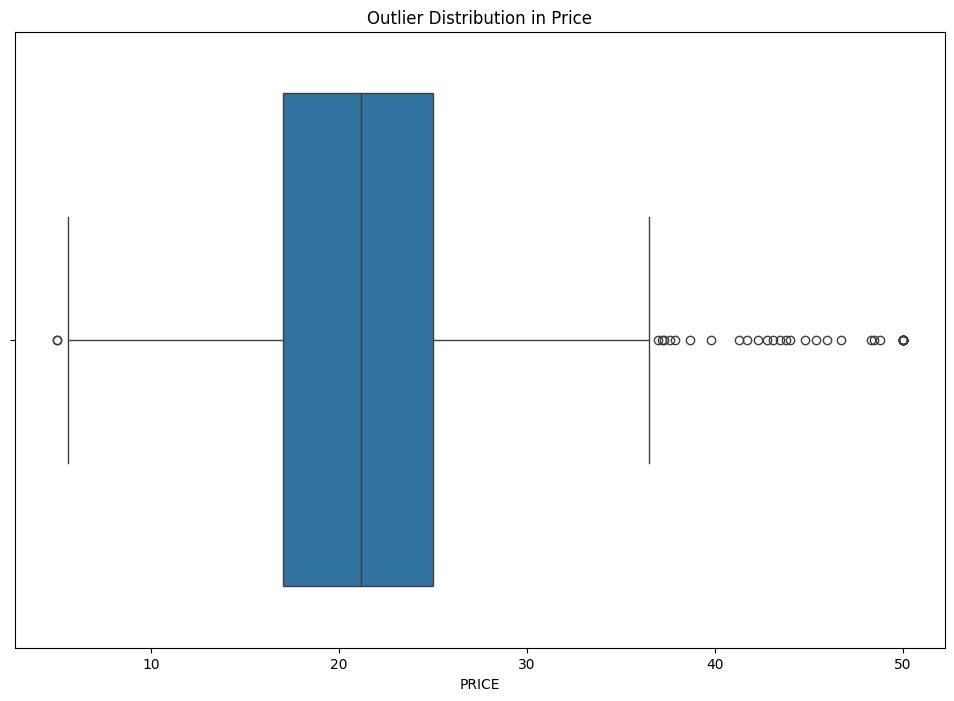

In [18]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df, x='PRICE')
plt.title('Outlier Distribution in Price')
plt.show()

## Histogram of Price

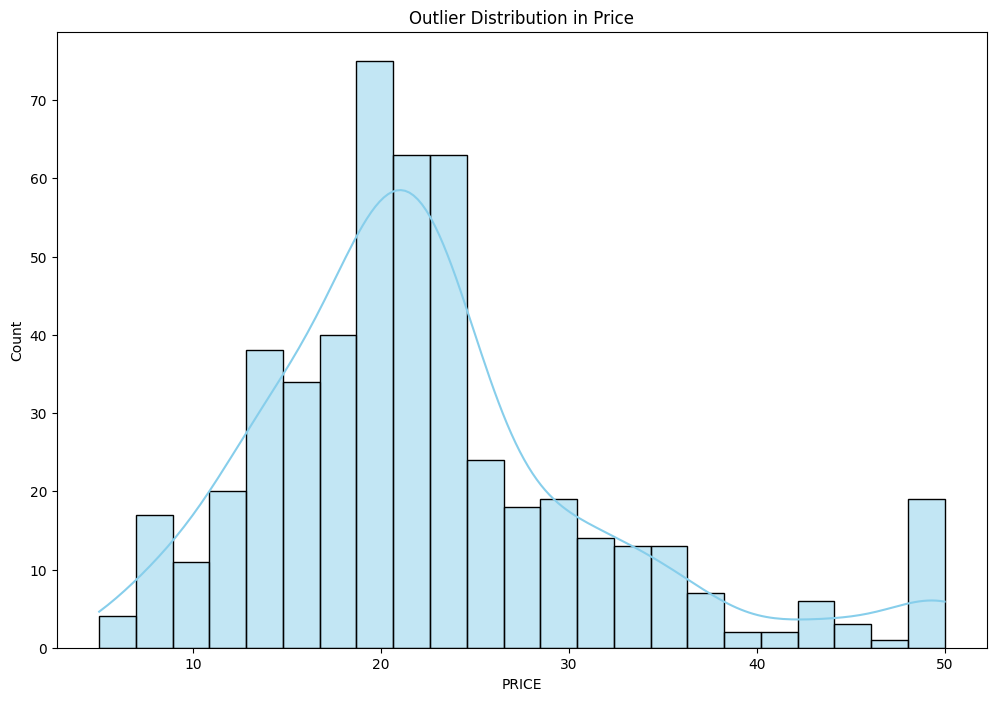

In [19]:
plt.figure(figsize=(12,8))
sns.histplot(data=df, x='PRICE', kde=True, color='skyblue')
plt.title('Outlier Distribution in Price')
plt.show()

## KDE for Price

C:\Users\Karunya\AppData\Local\Temp\ipykernel_3912\2127763612.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x='PRICE', data=df, shade=True)


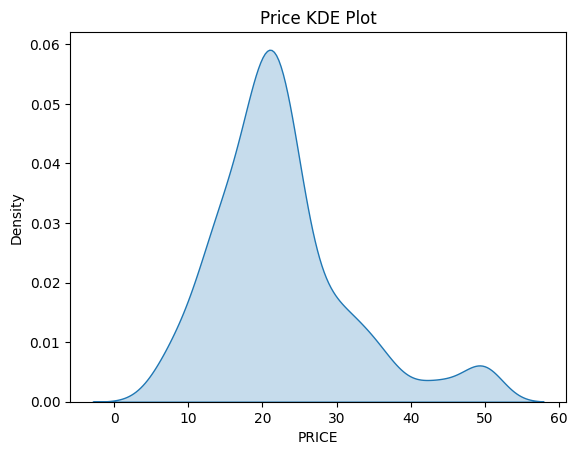

In [25]:
sns.kdeplot(x='PRICE', data=df, shade=True)
plt.title('Price KDE Plot')
plt.show()

## Price v/s Avg No. of Rooms

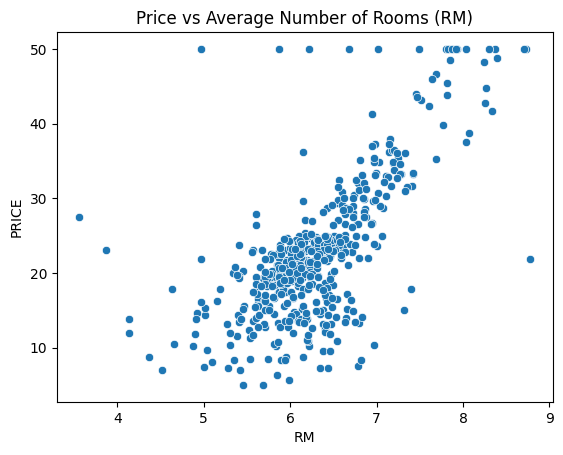

In [23]:
sns.scatterplot(x='RM', y='PRICE', data=df)
plt.title('Price vs Average Number of Rooms (RM)')
plt.show()

## Correlation Heatmap

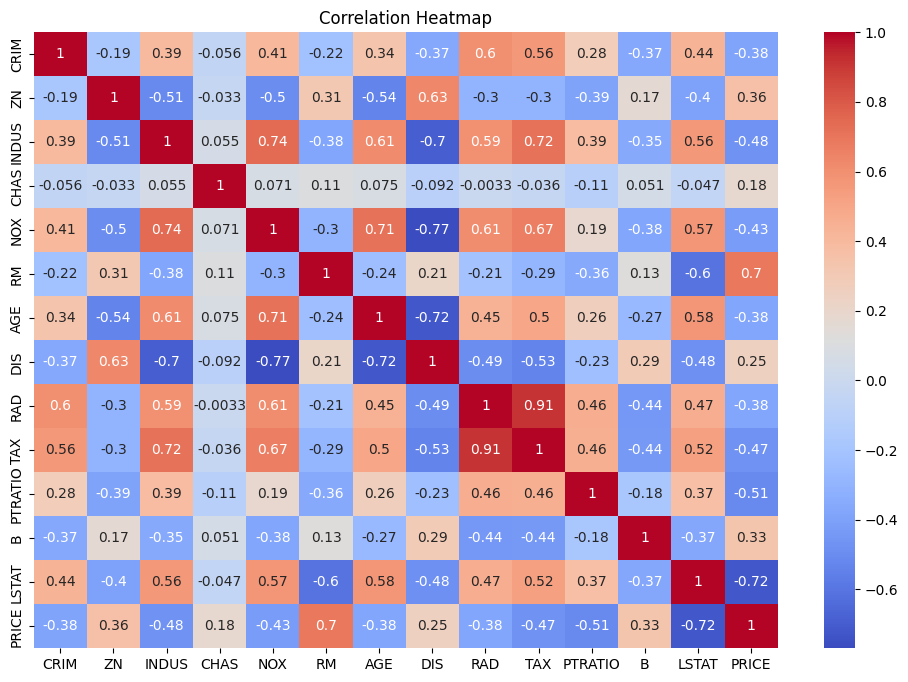

In [28]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Training Model

## Extract Target and Independent Features

In [29]:
y = df['PRICE']
x = df.drop('PRICE',axis=1)

In [30]:
print(f"No. of Rows in x : {x.shape[0]}\nNo. of Columns in x : {x.shape[1]}\nNo. of Rows in y : {y.shape[0]}")

No. of Rows in x : 506
No. of Columns in x : 13
No. of Rows in y : 506


## Splitting Dataset into Training and Testing

In [74]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.25, random_state=42)

In [75]:
print(f"Training Dataset Dimensions :\nx_train : {x_train.shape} | y_train : {y_train.shape}\nTesting Dataset Dimensions :\nx_test : {x_test.shape} | y_test : {y_test.shape}")

Training Dataset Dimensions :
x_train : (379, 13) | y_train : (379,)
Testing Dataset Dimensions :
x_test : (127, 13) | y_test : (127,)


In [76]:
display(x_train.head())

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
182,0.09103,0.0,2.46,0.0,0.4880,7.155,92.2,2.7006,3,193,17.8,394.12,4.82
155,3.53501,0.0,19.58,1.0,0.8710,6.152,76.8,1.7455,5,403,14.7,88.01,15.02
280,0.03578,20.0,3.33,0.0,0.4429,7.820,64.5,4.6947,5,216,14.9,387.31,3.76
126,0.38735,0.0,25.65,0.0,0.5810,5.613,76.8,1.7572,2,188,19.1,359.29,27.26
329,0.06724,0.0,3.24,0.0,0.4600,6.333,17.2,5.2146,4,430,16.9,375.21,7.34


In [77]:
display(y_train.head())

182    37.9
155    15.6
280    45.4
126    15.7
329    22.6
Name: PRICE, dtype: float64

## Training the Model

In [78]:
model = LinearRegression()

In [79]:
model.fit(x_train, y_train)

LinearRegression()

## Displaying Model Attributes

In [80]:
print(f"Model Intercept (c) : {model.intercept_}")

Model Intercept (c) : 27.650725409223377


In [81]:
print(f"Model Coefficients (m) :\n {model.coef_}")

Model Coefficients (m) :
 [-1.22056334e-01  2.49450306e-02 -1.95574600e-02  3.29430864e+00
 -1.50250479e+01  4.67349877e+00 -2.15726549e-02 -1.44607575e+00
  2.08351416e-01 -8.20620707e-03 -9.00277146e-01  1.28185783e-02
 -4.52221054e-01]


# Validating Model

## Predicting Using Model

In [82]:
y_pred = model.predict(x_test)

In [83]:
print(f"From Prediction : {y_pred[0]} v/s Actual : {y_test[0]}")
print(f"From Prediction : {y_pred[25]} v/s Actual : {y_test[25]}")

From Prediction : 28.9386633928857 v/s Actual : 24.0
From Prediction : 14.996005071788808 v/s Actual : 13.9


## Error and Accuracy of Model

In [84]:
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"📌 Mean Absolute Percentage Error (MAPE): {mape:.2%}\nAccuracy : {(1 - mape)*100}")

📌 Mean Absolute Percentage Error (MAPE): 15.80%
Accuracy : 84.20346627003728


## Visualizing using KDE Plot

C:\Users\Karunya\AppData\Local\Temp\ipykernel_3912\2572221256.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(y_test, label='Actual Price', shade=True)
C:\Users\Karunya\AppData\Local\Temp\ipykernel_3912\2572221256.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(y_pred, label='Predicted Price', shade=True, color='red')


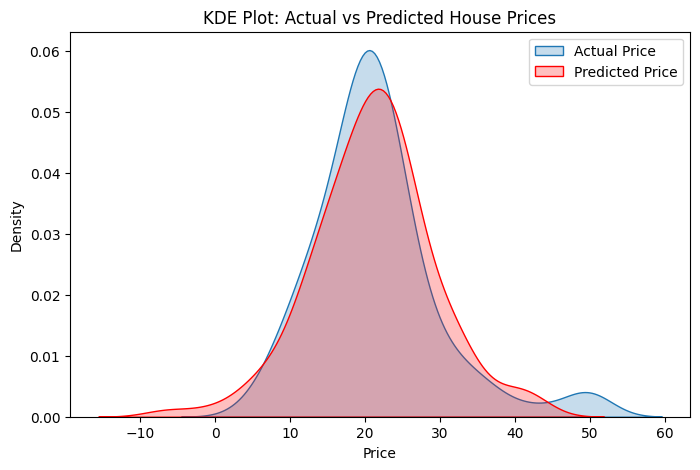

In [85]:
plt.figure(figsize=(8, 5))
sns.kdeplot(y_test, label='Actual Price', shade=True)
sns.kdeplot(y_pred, label='Predicted Price', shade=True, color='red')
plt.title('KDE Plot: Actual vs Predicted House Prices')
plt.xlabel('Price')
plt.ylabel('Density')
plt.legend()
plt.show()